# Feature research: when more predictors hurt temporal stability

**Question:** does a wider representation improve the original 700-feature
LightGBM control on later development periods? We tested 4,617 additional
hypotheses, retained 256 using earlier data, and completed four conditions
across all five expanding folds. The archived control contributes five reused
fits. Every condition covers the same 727,187 validation applications.

**Result:** the full engineered condition improves pooled AUC, average precision,
Brier and log loss, but reduces mean official stability from 0.585188 to 0.559904.
Doubling the original feature budget gives a small mean gain and a weaker worst
fold. These findings support retaining the frozen release; no result was promoted.

This is post-release exploratory development research. The original final holdout
was already opened and is not used here. The original tuning and blend decisions
also used these development periods; this is not a fresh independent evaluation.
Read [the frozen release](09_model_release.ipynb) for its separate final result.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

from home_credit.modeling.feature_research_report import FAMILIES, LABELS, WIDTHS, load_evidence

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
evidence = load_evidence(root)
result, screen = evidence["result"], evidence["screen"]
print("Verified complete study:", result["study_key"])
print("20 new comparison fits + 5 reused controls; 2 separate early-screen model fits.")
print("This review performs zero fits and requires no private data or cloud credentials.")
display(
    pd.DataFrame(
        [
            {
                "Original candidates": result["original_candidates"],
                "Additional hypotheses": screen["generated"],
                "Additional retained": screen["retained"],
                "Additional rejected": screen["rejected"],
                "Cases per condition": 727187,
            }
        ]
    )
)
display(pd.Series(screen["rejection_counts"], name="Rejected candidates").to_frame())

Verified complete study: 6e5fb0a67d28bf465142c2de8d8d1577632463bfa70d2d2413762c82ccc6b79e
20 new comparison fits + 5 reused controls; 2 separate early-screen model fits.
This review performs zero fits and requires no private data or cloud credentials.


,Original candidates,Additional hypotheses,Additional retained,Additional rejected,Cases per condition
0,2508,4617,256,4361,727187


,Rejected candidates
cardinality,26
constant,934
early_ranking_budget,1780
exact_duplicate,1458
missingness,97
near_constant,66


## Formulas, selection and availability

The original 2,508 features summarize 17 relational groups. The extension adds
ratios, dispersion, recency shares, household comparisons, category interactions,
missingness, source-order differences and training-population peer statistics.
These total 7,125 representations, not independent signals. Every new candidate
has source columns, an operation, a rationale and a recorded rejection decision.

Structural screening uses only training rows. Target and drift screeners fit
weeks 0-24 (160,000 sampled cases) and evaluate weeks 25-32 (80,000 cases), before
model-validation weeks 33-72. After constants, duplicates and near-constants,
2,159 additions remain; missingness/cardinality filters leave 2,036 eligible.
A fixed ranking budget retains 256. Early-window drift AUC is 0.998473, making
subsequent temporal testing essential. Screen metrics are not final CV results.

Positive ratios return null for missing or nonpositive denominators; relative
standard deviation is `std / abs(mean)` when `abs(mean) > 1e-8`, otherwise null.
Category combinations receive
training-fold frequency encoding. Each model fits its own peer references:
44 selected empirical ranks, three conditional median ratios and three conditional
interquartile positions. Ranks mostly re-express existing information. Unsupported
peer groups (fewer than 50 training cases) and unseen groups return null.

Source group order is **not verified chronology**. Historical quantiles/skew were
not recomputed from raw histories; peer quantiles describe training populations.
All features rely on the competition's application-time snapshots, without a
production guarantee about event timestamps or label maturity. CatBoost's native
target statistics were tested in the original benchmark; online default-rate
histories are not introduced without outcome-availability timestamps.

In [2]:
examples = [next(r for r in screen["selected"] if r["family"] == f) for f in FAMILIES]
with pd.option_context("display.max_colwidth", 110):
    display(pd.DataFrame(examples)[["family", "operation", "sources", "rationale"]])
display(
    pd.DataFrame(
        {"Candidates": result["candidate_families"], "Retained": result["retained_families"]}
    ).rename(index=FAMILIES)
)

,family,operation,sources,rationale
0,amount_ratios,positive_ratio,"[static_cb__d0__pmtssum_45A, static__d0__credamount_770A]","Recorded monetary activity relative to current credit, price or annuity; a relative exposure proxy, not a ..."
1,category_interactions,category_pair,"[person__d1__all__familystate_447L__first, applprev__d1__status_219L__first]",Joint category frequency is fitted only on the current training fold.
2,dispersion,relative_std,"[credit_bureau_a__d2__pmts_overdue_1140A__std, credit_bureau_a__d2__pmts_overdue_1140A__mean]",Variability relative to the magnitude of historical activity.
3,household,difference,"[person__d1__applicant__mainoccupationinc_384A__sum, person__d1__related__mainoccupationinc_384A__sum]",Applicant versus related-person context; no cross-customer outcome aggregation.
4,missingness,missing,[static_cb__d0__riskassesment_940T],Absence of a source measurement at application time.
5,peer_statistics,rank,[static__d0__avgdpdtolclosure24_3658938P],Empirical percentile against training cases only.
6,recency,positive_ratio,"[tax_registry_c__d1__processingdate_168D__count_last_30d, tax_registry_c__d1__processingdate_168D__count_l...",Recent events as a share of a longer window.
7,source_order,difference,"[tax_registry_c__d1__pmtamount_36A__last, tax_registry_c__d1__pmtamount_36A__first]",Change by num_group source order; not assumed to be chronological.


,Candidates,Retained
Amount ratios,1137,95
Category interactions,120,39
Dispersion,546,55
Household comparisons,193,4
Missingness,2179,4
Peer statistics,96,50
Recency shares,164,4
Source-order differences,182,5


## Controlled comparisons and model complexity

The four new conditions use the original LightGBM parameters, seeds, six-thread
configuration and five full folds. Only the representation changes. All 20 fits
retain native models, encoders, peer references, feature recipes and predictions.
The 700-feature control reuses its archived predictions. No learner was retuned
to rescue a weak feature condition.

Report mean and worst-fold stability alongside pooled ROC AUC, average precision,
raw Brier and log loss. Native-model size and selected boosting rounds expose
complexity; they are not inference-latency measurements. Different worker instance
families prevent treating job duration as a controlled speed comparison.

The official metric penalizes declining weekly Gini and residual variation.
Pooled discrimination can therefore improve while the primary temporal objective
worsens. Fold changes make that tradeoff visible. Permutation error bars show the
observed minimum/maximum across five folds and three repeats, **not confidence
intervals**. Permuting a whole added family within each week preserves its internal
relationships but breaks dependencies with unpermuted features. On 12,000 sampled
cases per fold, the slope penalty can produce wide ranges. Full-fold ablations
carry more weight than one noisy importance number.

,delta_vs_control,features,experiment,mean_fold_stability,oof_auc,oof_brier_score,oof_log_loss,oof_pr_auc,worst_fold_stability
0,0.001290,1400,wider_original,0.586478,0.847568,0.032396,0.126632,0.205616,0.362256
1,0.000000,700,control,0.585188,0.846894,0.032425,0.126805,0.204525,0.393682
2,-0.000553,861,without_amount_ratios,0.584635,0.846720,0.032426,0.126830,0.204632,0.416372
3,-0.025284,956,engineered,0.559904,0.848341,0.032385,0.126482,0.206339,0.317207
4,-0.029577,906,without_peer_statistics,0.555612,0.848207,0.032398,0.126536,0.205962,0.329406


rounds            native_model_MB              
                                 mean  min   max            mean    min    max
condition                                                                     
Original + additions (956)     1371.0  795  1813           5.038  2.965  6.614
Wider original 1,400           1351.6  773  1865           4.988  2.906  6.828
Without added ratios (861)     1250.2  597  1633           4.591  2.241  5.969
Without peer statistics (906)  1388.2  779  1807           5.090  2.899  6.584

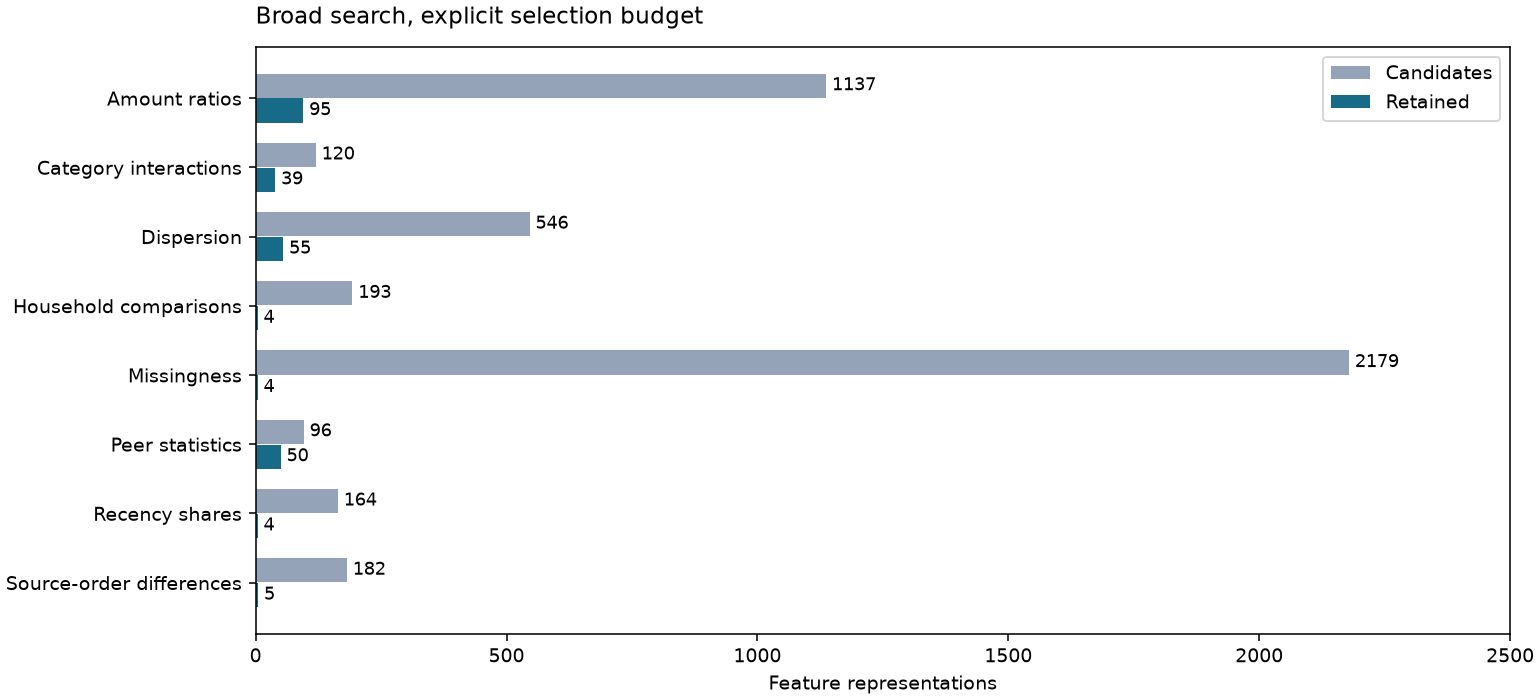

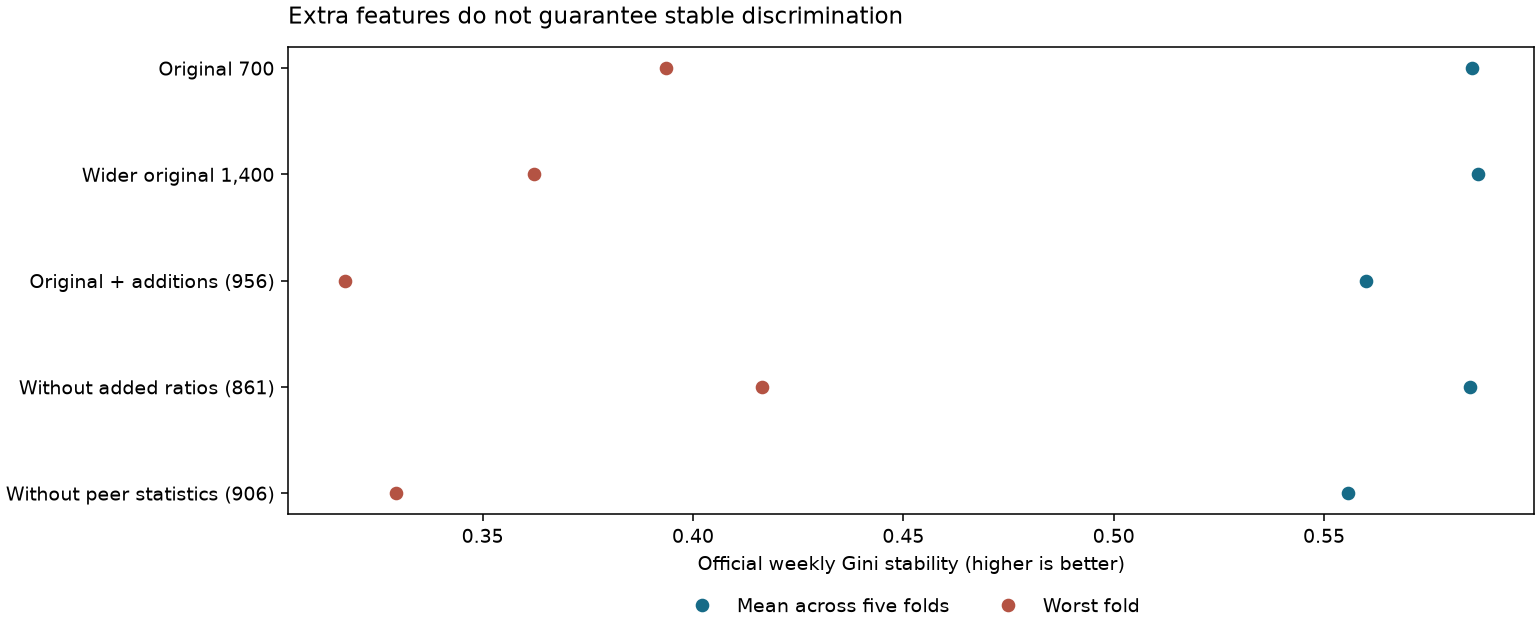

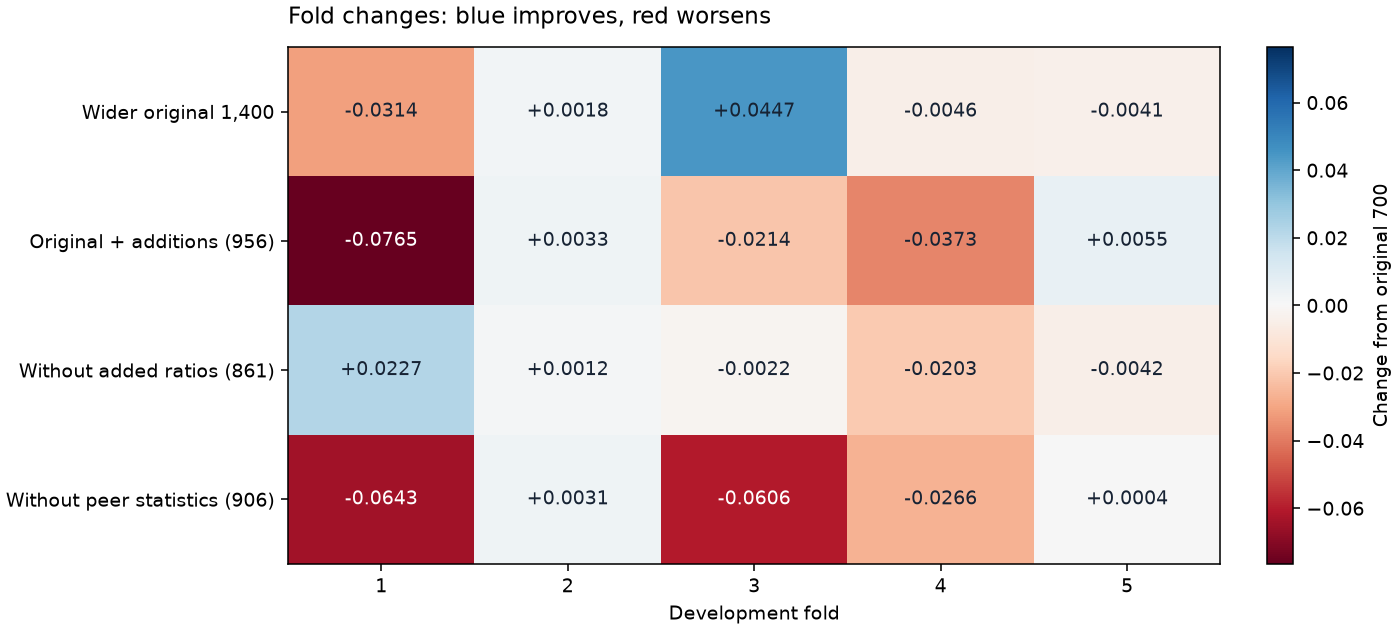

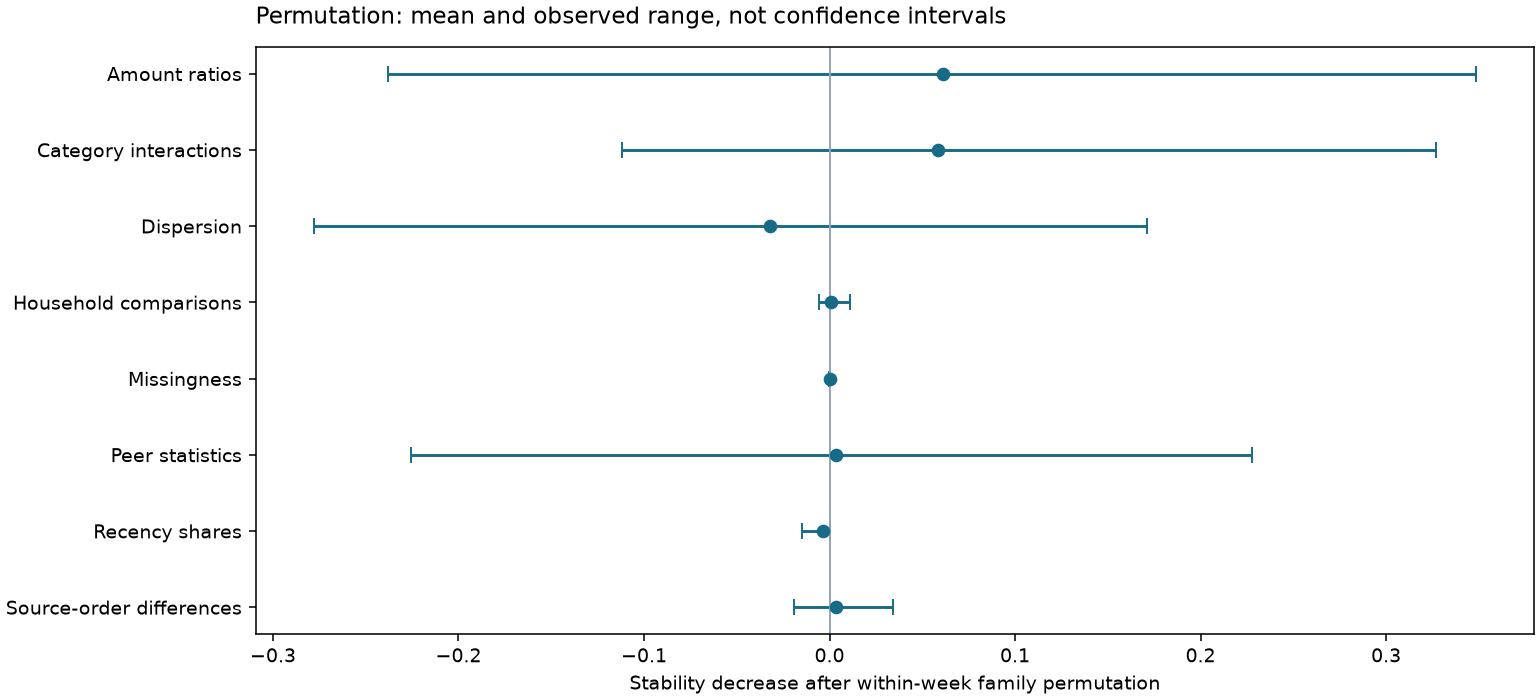

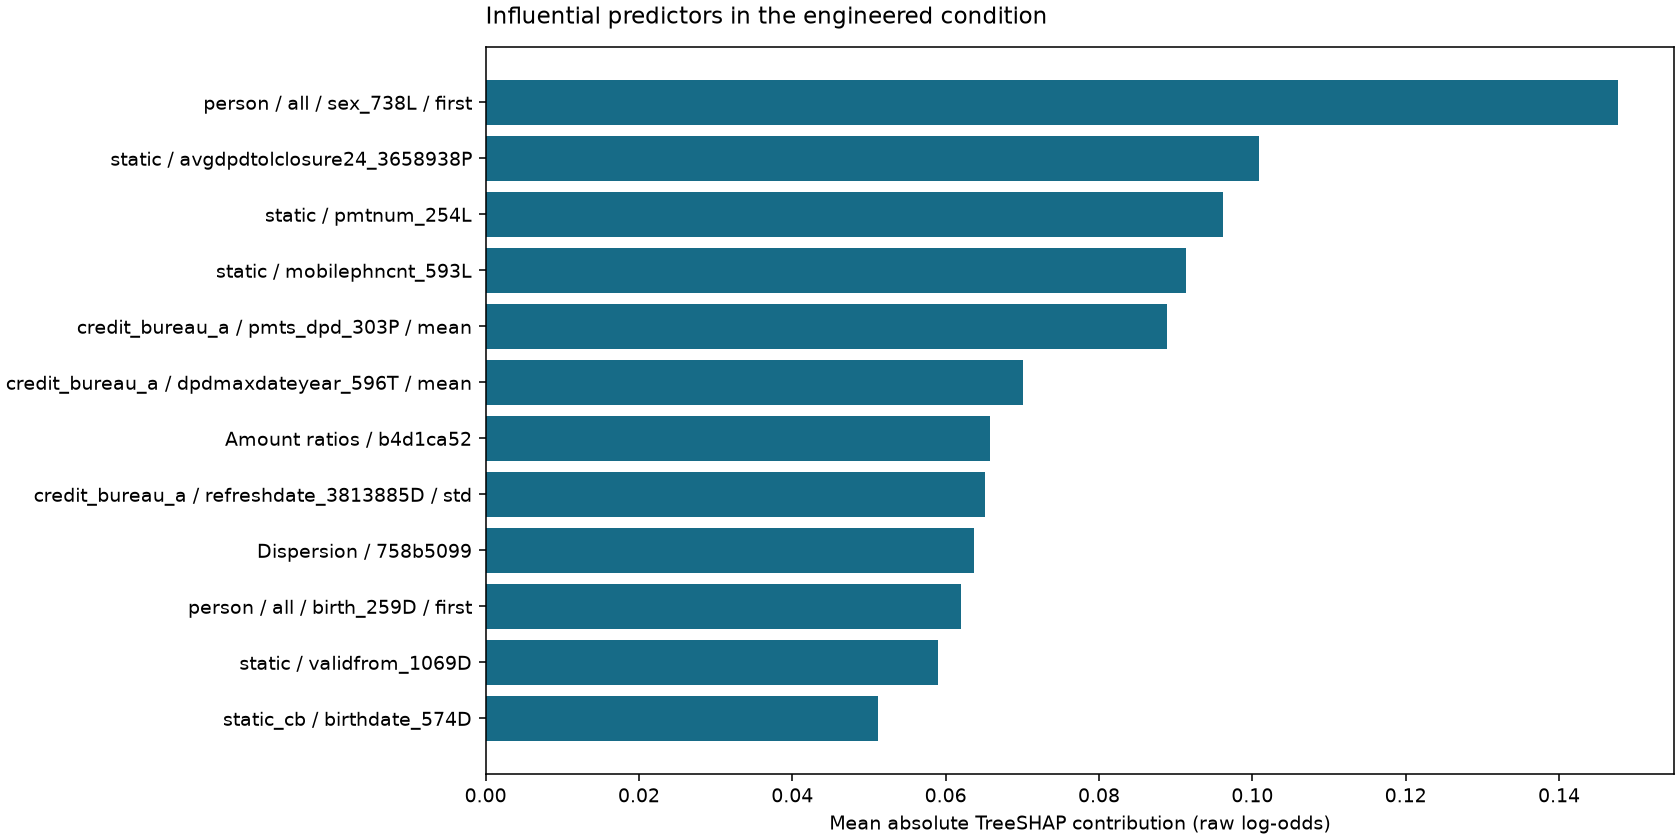

In [3]:
from home_credit.modeling.feature_research_report import display_charts

rows = pd.DataFrame(result["rows"])
rows.insert(1, "features", rows["experiment"].map(WIDTHS))
display(rows.round(6))
fits = pd.DataFrame(
    [
        {
            "condition": LABELS[r["experiment"]],
            "rounds": r["best_iteration"],
            "native_model_MB": r["artifacts"]["model"]["bytes"] / 1_000_000,
        }
        for r in result["fit_records"]
    ]
)
display(fits.groupby("condition").agg(["mean", "min", "max"]).round(3))
display_charts(evidence)

## Interpretation, redundancy and an audited correction

The first SHAP implementation selected a sorted sample prefix, which could
overrepresent earlier source-ordered cases. This publication uses the corrected
independent uniform sample of 512 cases from each complete validation fold.
All eight weeks are represented. A separate job replayed all 727,187 validation
predictions using saved native models, encoders and peer maps, with zero new fits.
It checked SHAP additivity and retained links to the original diagnostic hashes.

TreeSHAP values are raw log-odds contributions, averaged equally across the five
fold samples. The table shows variation and membership in each fold's top twenty.
Correlation pairs use up to 4,000 systematically spaced training cases, pairwise
complete values, and absolute correlation at least 0.98 among the 80 leading
gain-ranked encoded predictors. This is a targeted redundancy check, not a
complete dependence analysis.

Sex is the leading mean-absolute-SHAP predictor in this engineered condition;
birth-related features also rank highly. That is a disclosed modeling limitation,
not a fairness finding or justification for a credit decision. Interpretations
are predictive associations, not causal effects. The model card states that
this pipeline has not been validated for real lending decisions.

In [4]:
from home_credit.modeling.feature_research_report import importance_summary

importance = importance_summary(evidence)
with pd.option_context("display.max_colwidth", 100):
    display(importance.head(20).round(6))
    added = importance[importance["name"].str.startswith("research__")].head(5)
    rationale = pd.DataFrame(screen["selected"])
    display(
        added.merge(rationale, on=["name", "family"])[
            ["name", "mean_abs_shap", "operation", "sources", "rationale"]
        ].round(6)
    )
    redundant = pd.DataFrame(evidence["redundancy"])
    redundant = redundant.sort_values(["training_correlation", "fold"], ascending=[False, True])
    display(redundant.head(12))
checks = [
    {
        k: d[k]
        for k in [
            "fold",
            "replayed_predictions",
            "prediction_maximum_absolute_error",
            "shap_rows",
            "maximum_additivity_absolute_error",
            "new_model_fits",
            "peer_references_refitted",
        ]
    }
    for d in evidence["diagnostics"]
]
display(pd.DataFrame(checks))
weeks = pd.DataFrame(
    [{"fold": d["fold"], **w} for d in evidence["diagnostics"] for w in d["shap_week_counts"]]
)
display(weeks.pivot(index="fold", columns="WEEK_NUM", values="len").fillna(0).astype(int))
print("Independent metric recomputation:", evidence["verification"]["metric_comparisons"], "checks")
print("Maximum metric absolute error:", evidence["verification"]["maximum_metric_absolute_error"])

,name,family,mean_abs_shap,minimum,maximum,top20_folds
516,person__d1__all__sex_738L__first,person,0.147633,0.140595,0.162393,5
817,static__d0__avgdpdtolclosure24_3658938P,static,0.100919,0.090385,0.114034,5
903,static__d0__pmtnum_254L,static,0.096158,0.088807,0.102658,5
877,static__d0__mobilephncnt_593L,static,0.091349,0.084308,0.098074,5
442,credit_bureau_a__d2__pmts_dpd_303P__mean,credit_bureau_a,0.088839,0.081975,0.098756,5
251,credit_bureau_a__d1__dpdmaxdateyear_596T__mean,credit_bureau_a,0.070072,0.056933,0.083028,5
624,research__amount_ratios__positive_ratio__b4d1ca52d00e2a57,amount_ratios,0.065737,0.042293,0.086677,5
399,credit_bureau_a__d1__refreshdate_3813885D__std,credit_bureau_a,0.065169,0.014960,0.208642,2
728,research__dispersion__relative_std__758b50993da1998f,dispersion,0.063700,0.050800,0.077003,5
476,person__d1__all__birth_259D__first,person,0.061970,0.055319,0.068574,5


,name,mean_abs_shap,operation,sources,rationale
0,research__amount_ratios__positive_ratio__b4d1ca52d00e2a57,0.065737,positive_ratio,"[credit_bureau_a__d2__pmts_overdue_1140A__sum, static__d0__price_1097A]","Recorded monetary activity relative to current credit, price or annuity; a relative exposure pro..."
1,research__dispersion__relative_std__758b50993da1998f,0.063700,relative_std,"[credit_bureau_a__d2__pmts_overdue_1140A__std, credit_bureau_a__d2__pmts_overdue_1140A__mean]",Variability relative to the magnitude of historical activity.
2,research__category_interactions__category_pair__d077552e19c330b4,0.039687,category_pair,"[applprev__d1__education_1138M__last, person__d1__all__incometype_1044T__first]",Joint category frequency is fitted only on the current training fold.
3,research__dispersion__relative_std__3815d7bea5c92e5c,0.037058,relative_std,"[credit_bureau_a__d2__pmts_dpd_303P__std, credit_bureau_a__d2__pmts_dpd_303P__mean]",Variability relative to the magnitude of historical activity.
4,research__amount_ratios__positive_ratio__831c2c82cf22b44e,0.037033,positive_ratio,"[static__d0__annuity_780A, static__d0__price_1097A]","Recorded monetary activity relative to current credit, price or annuity; a relative exposure pro..."


,fold,a,b,paired_rows,training_correlation
0,1,static_cb__d0__birthdate_574D,person__d1__all__birth_259D__first,3809,1.000000
5,1,person__d1__all__birth_259D__max,person__d1__all__birth_259D__first,4000,1.000000
6,1,person__d1__all__birth_259D__max,static_cb__d0__birthdate_574D,3809,1.000000
8,2,static_cb__d0__birthdate_574D,person__d1__all__birth_259D__first,3134,1.000000
18,3,person__d1__all__empl_employedfrom_271D__max,person__d1__all__empl_employedfrom_271D__first,1634,1.000000
19,4,static_cb__d0__birthdate_574D,person__d1__all__birth_259D__first,2093,1.000000
15,3,static_cb__d0__birthdate_574D,person__d1__all__birth_259D__first,2501,1.000000
24,5,static_cb__d0__birthdate_574D,person__d1__all__birth_259D__first,1882,1.000000
31,5,static_cb__d0__dateofbirth_337D,static_cb__d0__birthdate_574D,1658,1.000000
30,5,static_cb__d0__dateofbirth_337D,person__d1__all__birth_259D__first,3595,0.999901


,fold,replayed_predictions,prediction_maximum_absolute_error,shap_rows,maximum_additivity_absolute_error,new_model_fits,peer_references_refitted
0,1,182576,0.0,512,2.220446e-14,0,False
1,2,194116,0.0,512,3.286260e-14,0,False
2,3,192561,0.0,512,3.197442e-14,0,False
3,4,126970,0.0,512,2.398082e-14,0,False
4,5,30964,0.0,512,2.575717e-14,0,False


WEEK_NUM,33,34,35,36,37,38,39,40,41,42,...,63,64,65,66,67,68,69,70,71,72
fold,,,,,,,,,,,,,,,,,,,,,
1,61,67,68,60,63,73,53,67,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,45,53,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,44,42,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,56,35,17,9,27,72,138,158


Independent metric recomputation: 235 checks
Maximum metric absolute error: 6.772360450213455e-15


## Decision and reproducible closure

- **All 256 additions:** mean stability falls by 0.025284 despite better pooled
  discrimination and probability scores. Feature influence alone does not justify
  inclusion in a model optimized for temporal stability.
- **Remove the 95 added ratios:** mean stability recovers by 0.024731 relative to
  the full extension, finishing 0.000553 below the control with a stronger worst
  fold. This is not a claim of statistical equivalence.
- **Remove 50 peer features:** mean stability falls another 0.004293 relative to
  the full extension, while its worst fold improves. Their utility is contextual.
- **Double the original budget:** mean rises by only 0.001290 and worst-fold
  stability falls by 0.031427, with twice the inputs. No significance claim follows.

**Decision: preserve the frozen tuned blend.** This extension has answered its
bounded research questions; it does not retroactively optimize the observed
holdout. Raw-history quantiles, neural challengers and fully nested promotion
studies remain possible future work, not unfinished requirements for this release.

Independent recomputation verified 21 prediction files, 3,635,935 predictions
across the five conditions and 235 metric identities. The original feature job
stopped at its time limit after 11 durable fits. Three workers supplied eight
disjoint late-fold fits; the collector resumed the one unfinished early-fold fit.
No completed model fit was repeated. The complete driver then restored all 20
checkpoints with **zero new fits**, and interpretation also demonstrated unchanged
zero-fit reuse. Recovery is at complete-fold boundaries, not mid-tree checkpoints.

This notebook validates committed aggregate evidence and can run without private
data. The catalog, comparison, ledgers, corrected diagnostics, verification script
and exact hashes are linked in [the research record](../reports/feature_research/README.md).
[Notebook 12](12_calibration.ipynb) separately tests temporal probability calibration.